In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [2]:
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/refs/heads/master/diabetes.csv"
df = pd.read_csv(url)

print("Original Dataset:")
print(df.head())
print(f"\nShape: {df.shape}")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print(f"\nTraining samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")


Original Dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape: (768, 9)

Training samples: 614
Test samples: 154


In [3]:
class DiabetesNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Architecture: 8 → 6 → 4 → 2
        self.network = nn.Sequential(
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )
    
    def forward(self, x):
        return self.network(x)

model = DiabetesNet()
print(model)


DiabetesNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=2, bias=True)
  )
)


In [4]:
X_train_tensor = torch.FloatTensor(x_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(x_test)
y_test_tensor = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 150


In [5]:
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = loss_func(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)
    
    # Test evaluation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = loss_func(outputs, y_batch)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    history['loss'].append(train_loss / len(train_loader))
    history['accuracy'].append(train_correct / train_total)
    history['val_loss'].append(val_loss / len(test_loader))
    history['val_accuracy'].append(val_correct / val_total)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {history['loss'][-1]:.4f} - accuracy: {history['accuracy'][-1]:.4f} - val_loss: {history['val_loss'][-1]:.4f} - val_accuracy: {history['val_accuracy'][-1]:.4f}")


Epoch 30/150 - loss: 0.5348 - accuracy: 0.7296 - val_loss: 0.5565 - val_accuracy: 0.7273
Epoch 60/150 - loss: 0.5101 - accuracy: 0.7590 - val_loss: 0.4876 - val_accuracy: 0.7857
Epoch 90/150 - loss: 0.4937 - accuracy: 0.7655 - val_loss: 0.4891 - val_accuracy: 0.7727
Epoch 120/150 - loss: 0.4771 - accuracy: 0.7476 - val_loss: 0.4570 - val_accuracy: 0.7922
Epoch 150/150 - loss: 0.5072 - accuracy: 0.7590 - val_loss: 0.4832 - val_accuracy: 0.7792


In [6]:
scores = [history['val_loss'][-1], history['val_accuracy'][-1]]
print(f"\nTest loss: {scores[0]:.2f}")
print(f"Test accuracy: {scores[1]*100:.2f}%")



Test loss: 0.48
Test accuracy: 77.92%


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


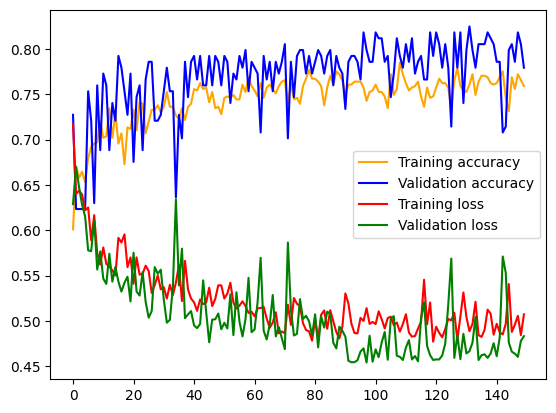

In [7]:
print(history.keys())

plt.figure()
plt.plot(history['accuracy'], 'orange', label='Training accuracy')
plt.plot(history['val_accuracy'], 'blue', label='Validation accuracy')
plt.plot(history['loss'], 'red', label='Training loss')
plt.plot(history['val_loss'], 'green', label='Validation loss')
plt.legend()
plt.show()


In [8]:
new_patient = np.array([[2, 197, 70, 45, 543, 30.5, 0.158, 53]])

model.eval()
with torch.no_grad():
    prediction = torch.softmax(model(torch.FloatTensor(new_patient)), dim=1)

if torch.argmax(prediction).item() > 0.5:
    print("The patient is predicted to have diabetes.")
else:
    print("The patient is predicted to be healthy.")
    
print(f"Confidence: {prediction[0][1].item()*100:.2f}%")


The patient is predicted to have diabetes.
Confidence: 68.16%


In [9]:
print("Before normalization:")
print(x_train[:3])

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("\nAfter normalization:")
print(x_train_scaled[:3])


Before normalization:
[[3.00e+00 1.15e+02 6.60e+01 3.90e+01 1.40e+02 3.81e+01 1.50e-01 2.80e+01]
 [3.00e+00 1.13e+02 5.00e+01 1.00e+01 8.50e+01 2.95e+01 6.26e-01 2.50e+01]
 [5.00e+00 1.58e+02 8.40e+01 4.10e+01 2.10e+02 3.94e+01 3.95e-01 2.90e+01]]

After normalization:
[[-0.23288296 -0.19254286 -0.14765856  1.16039156  0.53295812  0.77091625
  -0.96082409 -0.44505367]
 [-0.23288296 -0.25623969 -0.97092627 -0.66825983  0.04416108 -0.35899914
   0.5132899  -0.70244421]
 [ 0.36918077  1.17693899  0.77851761  1.28650544  1.15506343  0.94171741
  -0.20208895 -0.35925682]]


In [10]:
model_normalized = DiabetesNet()
optimizer_norm = torch.optim.Adam(model_normalized.parameters(), lr=0.01)

X_train_scaled_tensor = torch.FloatTensor(x_train_scaled)
X_test_scaled_tensor = torch.FloatTensor(x_test_scaled)

train_loader_norm = DataLoader(TensorDataset(X_train_scaled_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader_norm = DataLoader(TensorDataset(X_test_scaled_tensor, y_test_tensor), batch_size=32)

history_norm = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    model_normalized.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader_norm:
        outputs = model_normalized(X_batch)
        loss = loss_func(outputs, y_batch)
        
        loss.backward()
        optimizer_norm.step()
        optimizer_norm.zero_grad()
        
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)
    
    model_normalized.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader_norm:
            outputs = model_normalized(X_batch)
            loss = loss_func(outputs, y_batch)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    history_norm['loss'].append(train_loss / len(train_loader_norm))
    history_norm['accuracy'].append(train_correct / train_total)
    history_norm['val_loss'].append(val_loss / len(test_loader_norm))
    history_norm['val_accuracy'].append(val_correct / val_total)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {history_norm['loss'][-1]:.4f} - accuracy: {history_norm['accuracy'][-1]:.4f} - val_loss: {history_norm['val_loss'][-1]:.4f} - val_accuracy: {history_norm['val_accuracy'][-1]:.4f}")

print(f"\nNormalized model test accuracy: {history_norm['val_accuracy'][-1]*100:.2f}%")


Epoch 30/150 - loss: 0.4180 - accuracy: 0.7997 - val_loss: 0.5467 - val_accuracy: 0.7662
Epoch 60/150 - loss: 0.3969 - accuracy: 0.8176 - val_loss: 0.6146 - val_accuracy: 0.7208
Epoch 90/150 - loss: 0.3826 - accuracy: 0.8225 - val_loss: 0.6554 - val_accuracy: 0.7403
Epoch 120/150 - loss: 0.3567 - accuracy: 0.8322 - val_loss: 0.7287 - val_accuracy: 0.7273
Epoch 150/150 - loss: 0.3577 - accuracy: 0.8371 - val_loss: 0.7744 - val_accuracy: 0.7143

Normalized model test accuracy: 71.43%


In [11]:
new_patient_scaled = scaler.transform(new_patient)

model_normalized.eval()
with torch.no_grad():
    prediction_norm = torch.softmax(model_normalized(torch.FloatTensor(new_patient_scaled)), dim=1)

if torch.argmax(prediction_norm).item() > 0.5:
    print("The patient is predicted to have diabetes.")
else:
    print("The patient is predicted to be healthy.")
    
print(f"Confidence: {prediction_norm[0][1].item()*100:.2f}%")


The patient is predicted to have diabetes.
Confidence: 76.93%


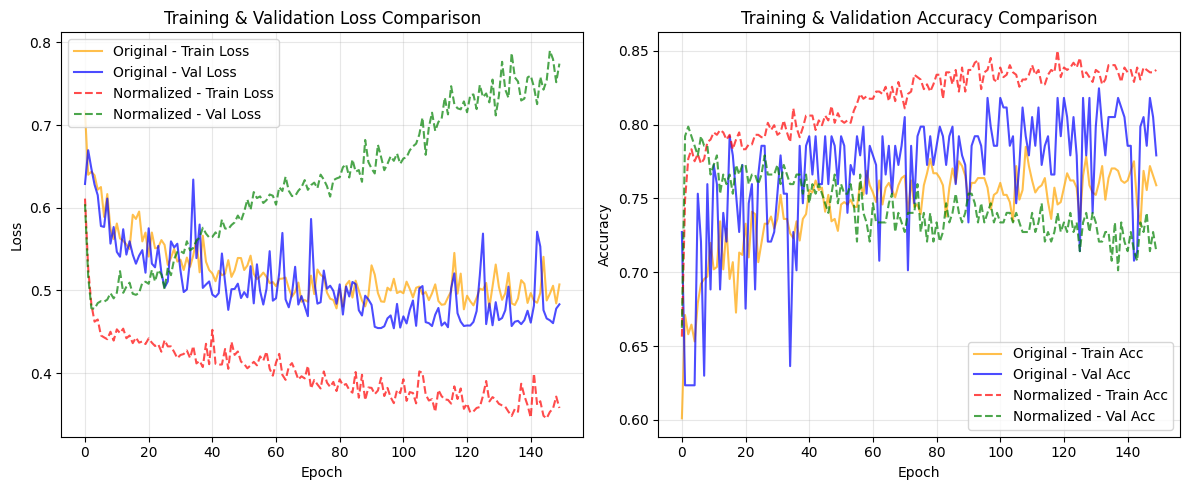

In [12]:
# Comparison: Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Original - Train Loss', color='orange', alpha=0.7)
plt.plot(history['val_loss'], label='Original - Val Loss', color='blue', alpha=0.7)
plt.plot(history_norm['loss'], label='Normalized - Train Loss', color='red', linestyle='--', alpha=0.7)
plt.plot(history_norm['val_loss'], label='Normalized - Val Loss', color='green', linestyle='--', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Original - Train Acc', color='orange', alpha=0.7)
plt.plot(history['val_accuracy'], label='Original - Val Acc', color='blue', alpha=0.7)
plt.plot(history_norm['accuracy'], label='Normalized - Train Acc', color='red', linestyle='--', alpha=0.7)
plt.plot(history_norm['val_accuracy'], label='Normalized - Val Acc', color='green', linestyle='--', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
print("\nFinal Results:")
print("="*60)
print(f"Original Model:")
print(f"  Best Test Accuracy: {max(history['val_accuracy'])*100:.2f}%")
print(f"  Final Test Loss: {history['val_loss'][-1]:.4f}")
print(f"\nNormalized Model:")
print(f"  Best Test Accuracy: {max(history_norm['val_accuracy'])*100:.2f}%")
print(f"  Final Test Loss: {history_norm['val_loss'][-1]:.4f}")
print("="*60)



Final Results:
Original Model:
  Best Test Accuracy: 82.47%
  Final Test Loss: 0.4832

Normalized Model:
  Best Test Accuracy: 79.87%
  Final Test Loss: 0.7744
